BEGINNER TASKS 1
Submitted by Adeshina Toluwalope Emmanuel

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd
df=pd.read_csv('train.csv')
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1.0,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1.0,BABY CARE,0.0,0.0
2,2,2013-01-01,1.0,BEAUTY,0.0,0.0
3,3,2013-01-01,1.0,BEVERAGES,0.0,0.0
4,4,2013-01-01,1.0,BOOKS,0.0,0.0


In [13]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506167 entries, 0 to 506166
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           506167 non-null  int64  
 1   date         506167 non-null  object 
 2   store_nbr    506166 non-null  float64
 3   family       506166 non-null  object 
 4   sales        506166 non-null  float64
 5   onpromotion  506166 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 23.2+ MB


In [15]:
print(df.isnull().sum())

id             0
date           0
store_nbr      1
family         1
sales          1
onpromotion    1
dtype: int64


In [16]:
df.describe(include='all')

,id,date,store_nbr,family,sales,onpromotion
count,506167.00000,506167,506166.000000,506166,506166.000000,506166.0
unique,NaN,286,NaN,33,NaN,NaN
top,NaN,2013-10-11,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,1782,NaN,15339,NaN,NaN
mean,253083.00000,NaN,27.496740,NaN,207.246762,0.0
std,146117.97119,NaN,15.586915,NaN,698.000049,0.0
min,0.00000,NaN,1.000000,NaN,0.000000,0.0
25%,126541.50000,NaN,14.000000,NaN,0.000000,0.0
50%,253083.00000,NaN,27.000000,NaN,0.000000,0.0
75%,379624.50000,NaN,41.000000,NaN,96.360000,0.0


In [19]:
import pandas as pd
df = pd.read_csv('train.csv')
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


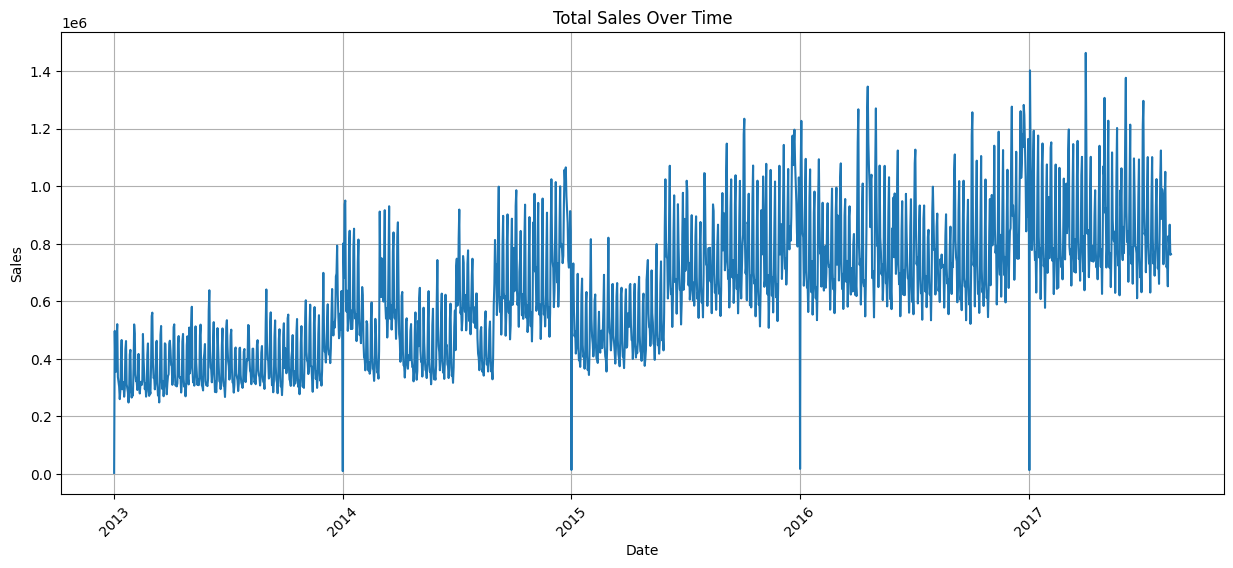

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
df['date'] = pd.to_datetime(df['date'])
sales_trend = df.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(15,6))
plt.plot(sales_trend['date'],sales_trend['sales'])
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

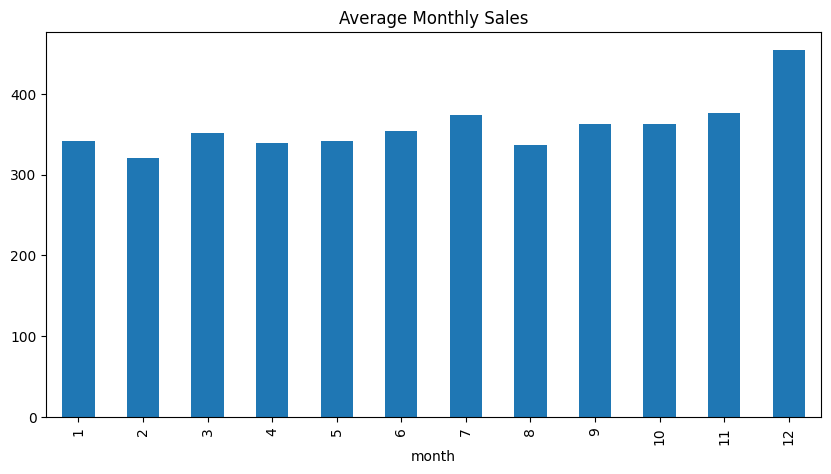

In [22]:
df['month'] = df['date'].dt.month

monthly_sales = df.groupby('month')['sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title('Average Monthly Sales')
plt.show()

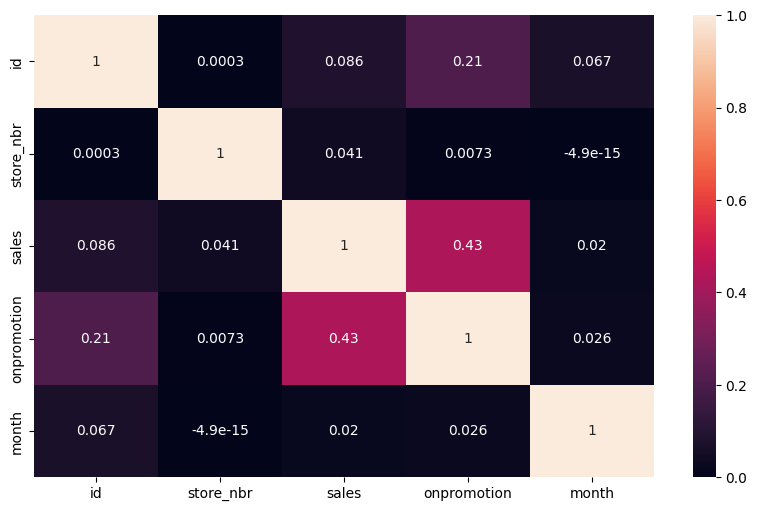

In [23]:
numeric_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

BEGINNER TASK 2 MOVING AVERAGE FORECAST

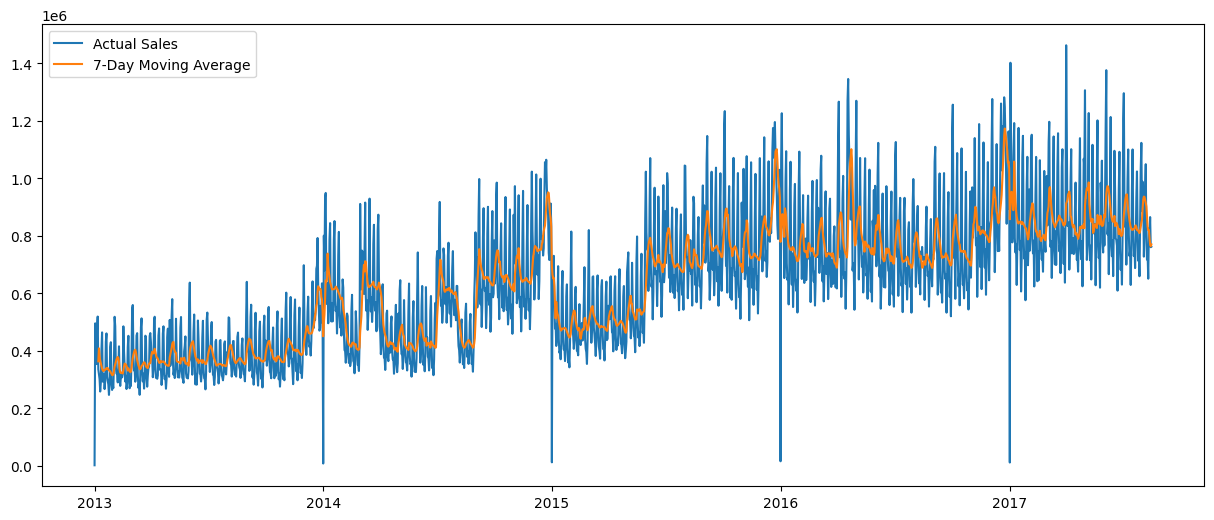

In [24]:
sales_trend = sales_trend.reset_index()
sales_trend['7_day_MA'] = sales_trend['sales'].rolling(window=7).mean()

plt.figure(figsize=(15,6))
plt.plot(sales_trend['date'], sales_trend['sales'], label='Actual Sales')
plt.plot(sales_trend['date'], sales_trend['7_day_MA'], label='7-Day Moving Average')
plt.legend()
plt.show()

INTERMEDIATE TASK 1 FEATURE ENGINEERING

In [26]:
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

In [27]:
df = df.sort_values('date')

df['lag_7'] = df['sales'].shift(7)
df['lag_30'] = df['sales'].shift(30)

In [30]:
df['rolling_mean_7'] = df['sales'].rolling(7).mean()

In [32]:
print(df)

              id       date  store_nbr         family    sales  onpromotion  \
0              0 2013-01-01          1     AUTOMOTIVE    0.000            0   
1194        1194 2013-01-01         42    CELEBRATION    0.000            0   
1193        1193 2013-01-01         42   BREAD/BAKERY    0.000            0   
1192        1192 2013-01-01         42          BOOKS    0.000            0   
1191        1191 2013-01-01         42      BEVERAGES    0.000            0   
...          ...        ...        ...            ...      ...          ...   
2999693  2999693 2017-08-15         25   PET SUPPLIES    3.000            0   
2999692  2999692 2017-08-15         25  PERSONAL CARE   93.000            8   
2999691  2999691 2017-08-15         25          MEATS  180.107            0   
2999702  2999702 2017-08-15         26         BEAUTY    0.000            0   
3000887  3000887 2017-08-15          9        SEAFOOD   16.000            0   

         month  weekday  is_weekend     lag_7      

ADVANCED LEVEL TASK — PART 1 Regularized Regression (Ridge & Lasso)

In [34]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

df['date']= pd.to_datetime(df['date'])
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day']=df['date'].dt.day

features_cols =['year','month','day']
x = df[features_cols]
y = df['sales']

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)